In [1]:
import pandas as pd

path = "USA_cars_datasets.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

display(df.head())

Shape: (2499, 13)

Columns:
Index(['Unnamed: 0', 'price', 'brand', 'model', 'year', 'title_status',
       'mileage', 'color', 'vin', 'lot', 'state', 'country', 'condition'],
      dtype='object')


,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [2]:
# drop useless index column
df = df.drop(columns=["Unnamed: 0"])

# ensure numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# quick check
print("Missing values:")
print(df[["price","mileage","brand","condition"]].isna().sum())

display(df.head())

Missing values:
price        0
mileage      0
brand        0
condition    0
dtype: int64


,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


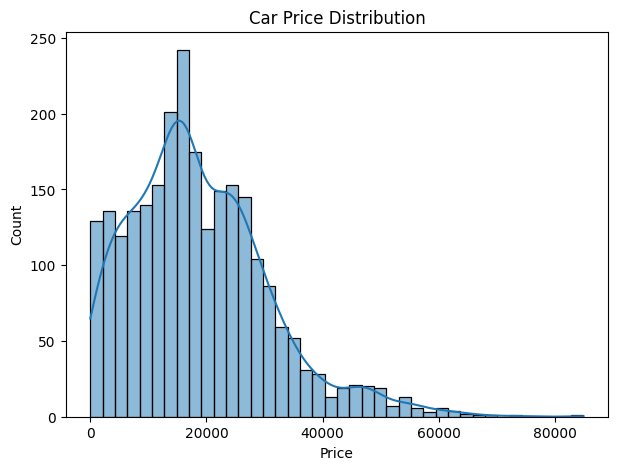

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.histplot(df["price"], bins=40, kde=True)

plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

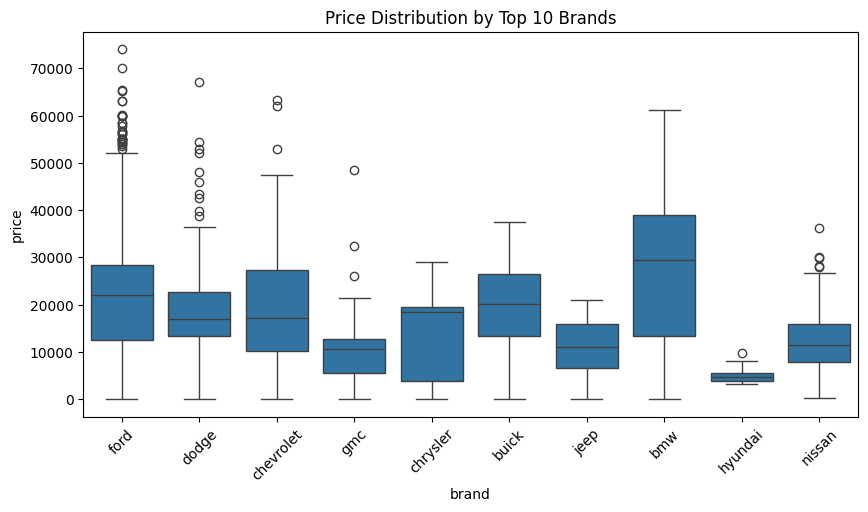

In [4]:
# top 10 brands
top_brands = df["brand"].value_counts().head(10).index

df_top = df[df["brand"].isin(top_brands)]

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_top,
    x="brand",
    y="price"
)

plt.xticks(rotation=45)
plt.title("Price Distribution by Top 10 Brands")

plt.show()

In [5]:
# pip install plotly
import plotly.express as px

fig = px.scatter(
    df,
    x="mileage",
    y="price",
    color="condition",
    title="Price vs Mileage (Interactive)"
)

fig.show()

In [ ]:
#  final conclusion

# The car price distribution is right-skewed, with most vehicles priced between 5,000 and 25,000 and a small number of high-price outliers.

# Price varies significantly by brand. Luxury brands such as BMW show higher median prices, while brands like Hyundai tend to have lower price ranges.

# The scatter plot reveals a clear negative relationship between mileage and price, indicating that vehicles with higher mileage generally sell for less.

# Overall, brand and mileage are major factors influencing car prices, while condition reflects auction timing rather than vehicle quality.